Stripe only downlink example
----------------------------
This notebook shows how to use the stripe to send a QAM signal downlink towards the active radio unit. The signal travels up to the antenna of the active radio unit. Varying the fiber, coupler and amplifier parameters allows to inspect their impact on the AM/AM and PSD plots. These are plotted at the end of the notebook for every stage in the link.

In [13]:
import yaml
import numpy as np

from plotter import plotter
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.amplifier.amplifier import Amplifier
from sub_THz_stripe.combiner.combiner import Combiner
from sub_THz_stripe.coupler.coupler import Coupler
from sub_THz_stripe.phase_shifter.phase_shifter import PhaseShifter
from sub_THz_stripe.splitter.splitter import Splitter
from sub_THz_stripe.utils import calculate_papr

In [14]:
environment = "office_space_inline"

# Read out the config file.
config_file = f"environments/{environment}/config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

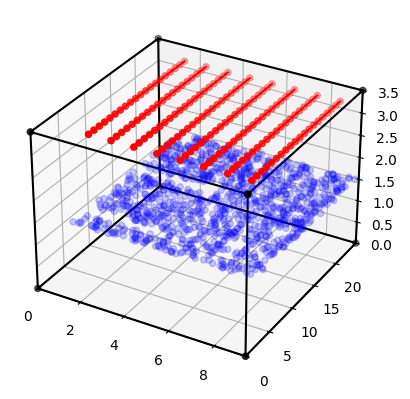

In [15]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [16]:
# Read out the Waveform config file.
config_file = "environments/waveform_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    waveform_config = yaml.safe_load(file)

# Construct the waveform class based on the loaded configuration.
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

ue_pos = None
for ue in config["ue_positions"]:
    if ue["x"] == 2.0 and ue["y"] == 21.5 and ue["z"] == 1.5:
        ue_pos = ue
        break

In [17]:
# Read out the Component config file.
config_file = "environments/component_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    component_config = yaml.safe_load(file)

# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, config["antenna"]["N_antennas"], wf))

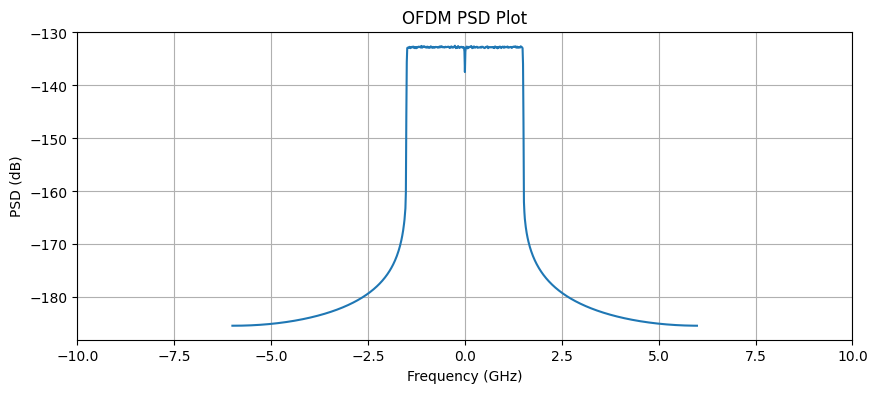

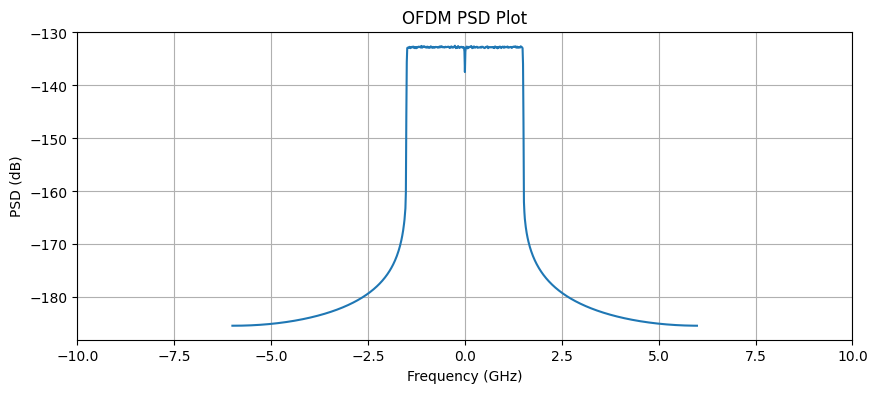

In [18]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)
wf.plot_psd()

In [19]:

cu = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_cu = cu.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

In [20]:
def calculate_papr(data, percentile: float = 99.5):
    """Calculate the PAPR of and OFDM signal.

    Arguments
    ---------
        data np.ndarray
            The input data for which to calculate the PAPR.
        percentile float
            For which percentile to calculate the PAPR.
    
    Returns
    -------
        The PAPR in dB.
    """
    abs_data = np.abs(data)
    threshold = np.percentile(abs_data, percentile)
    sdata = abs_data[abs_data < threshold]

    papr = np.max(sdata ** 2) / np.mean(abs_data ** 2)

    return 10 * np.log10(papr)

print(f"PAPR 99.5th percintile: {calculate_papr(ofdm_time)} dB")

power = np.abs(ofdm_time)**2
papr = 10 * np.log10(np.max(power) / np.mean(power))
print(f'worse case PAPR max/mean: {papr}')

PAPR 99.5th percintile: 7.246330553700998 dB
worse case PAPR max/mean: 11.196472749394133


7.246330553700998
Noise variance: -63.07555014831401 dBm
Noise variance: -63.0650410621918 dBm
Noise variance: -63.0676790964625 dBm
Noise variance: -63.058832108874284 dBm
Noise variance: -63.0719185622017 dBm
Noise variance: -63.06695371711478 dBm
Noise variance: -63.05625972797654 dBm
Noise variance: -63.04776461368786 dBm
Noise variance: -63.07046466702612 dBm
Noise variance: -63.06727843985749 dBm
Noise variance: -63.05368303129875 dBm
Noise variance: -63.05642769098577 dBm
Noise variance: -63.064711419912804 dBm
Noise variance: -63.06169560441014 dBm
Noise variance: -63.040849194562725 dBm
Noise variance: -63.070729247688575 dBm
Noise variance: -63.075216688604385 dBm
Noise variance: -63.06445714574964 dBm
Noise variance: -63.06913674553228 dBm
Noise variance: -63.05722094767036 dBm
Noise variance: -63.07897835822466 dBm
Noise variance: -63.04863545536962 dBm
Noise variance: -63.05744650435378 dBm
Noise variance: -63.06689063672246 dBm
Noise variance: -63.04687850687807 dBm
Noise

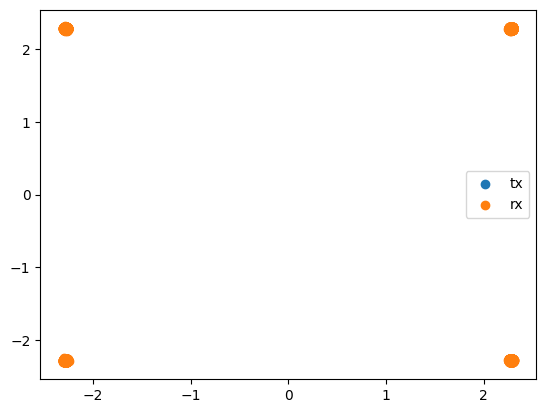

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage0: -8.0 dBm
Psig stage0: -8.0 dBm
Pnoise stage0: -58.603757029226784 dBm
NMSE stage0: -50.609655608765664 dB
Noise variance: -63.059968451245624 dBm


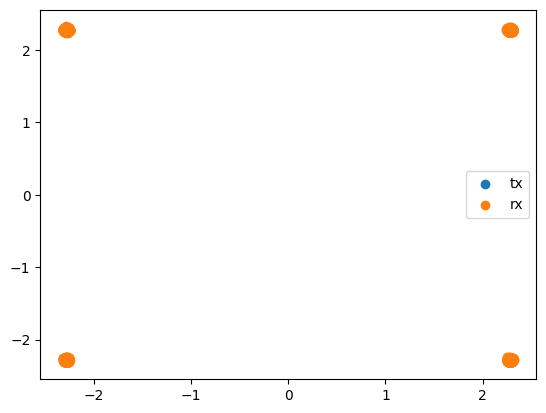

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage1: -8.050847579720601 dBm
Psig stage1: -8.0 dBm
Pnoise stage1: -55.580915622091254 dBm
NMSE stage1: -47.581867609133724 dB
Noise variance: -63.063723126736726 dBm


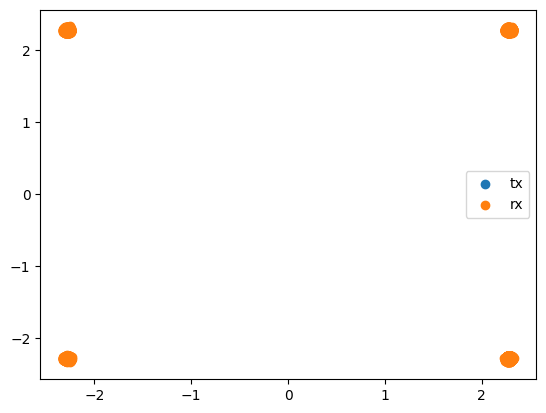

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage2: -8.09344233715284 dBm
Psig stage2: -8.0 dBm
Pnoise stage2: -53.78576165936951 dBm
NMSE stage2: -45.79033543226161 dB
Noise variance: -63.061916538036336 dBm


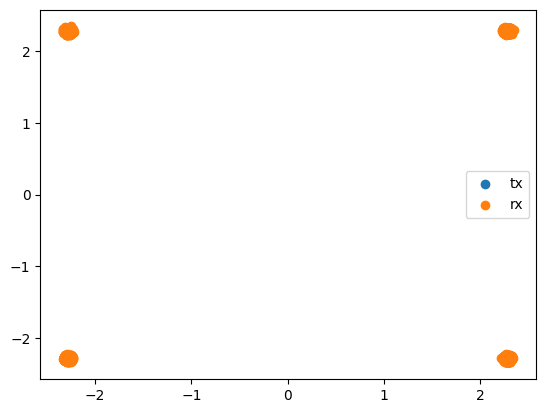

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage3: -8.134619266241215 dBm
Psig stage3: -8.0 dBm
Pnoise stage3: -52.508512101351165 dBm
NMSE stage3: -44.51162556398768 dB
Noise variance: -63.06367603190296 dBm


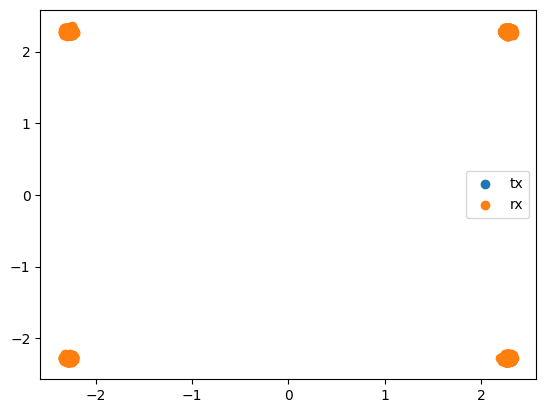

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage4: -8.169559834022067 dBm
Psig stage4: -8.0 dBm
Pnoise stage4: -51.508064665990815 dBm
NMSE stage4: -43.51187392158962 dB
Noise variance: -63.066729068664685 dBm


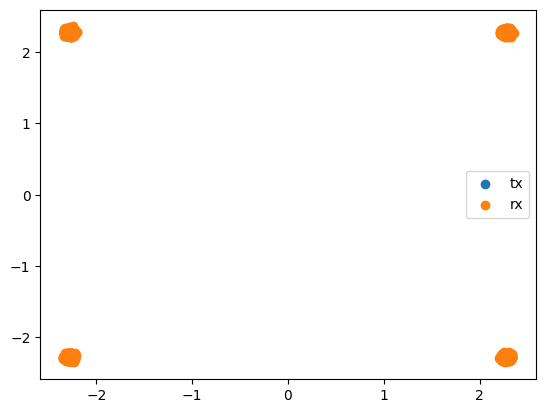

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage5: -8.198960346325668 dBm
Psig stage5: -8.0 dBm
Pnoise stage5: -50.65776098564554 dBm
NMSE stage5: -42.66140874638022 dB
Noise variance: -63.081381303213455 dBm


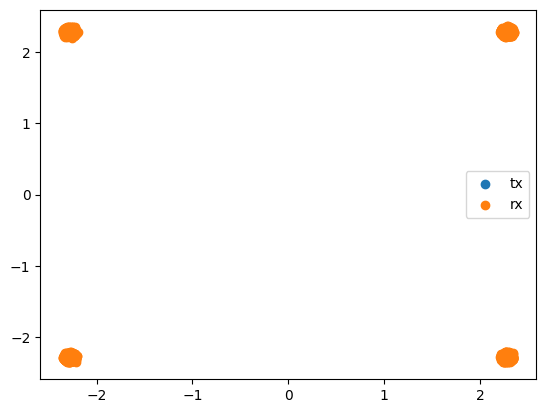

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage6: -8.219382976456947 dBm
Psig stage6: -8.0 dBm
Pnoise stage6: -49.95122803033263 dBm
NMSE stage6: -41.95316235192631 dB
Noise variance: -63.05446049392568 dBm


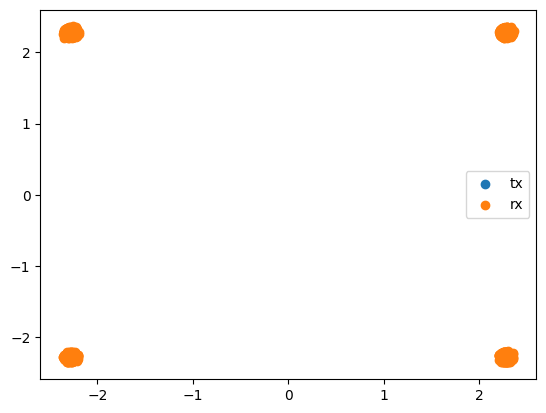

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage7: -8.23551606655948 dBm
Psig stage7: -8.0 dBm
Pnoise stage7: -49.30221569454645 dBm
NMSE stage7: -41.302239831118406 dB
Noise variance: -63.05416092714209 dBm


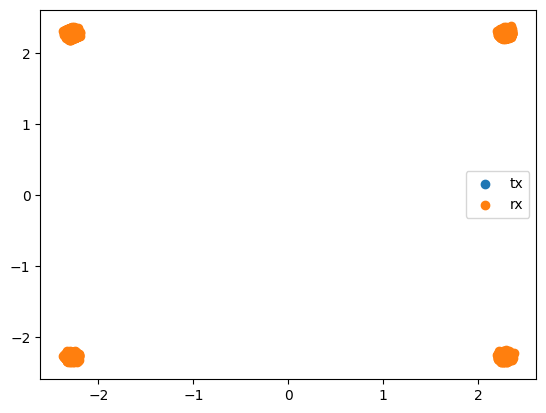

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage8: -8.244623846681765 dBm
Psig stage8: -8.0 dBm
Pnoise stage8: -48.751437818827156 dBm
NMSE stage8: -40.75353692367767 dB
Noise variance: -63.07740202211675 dBm


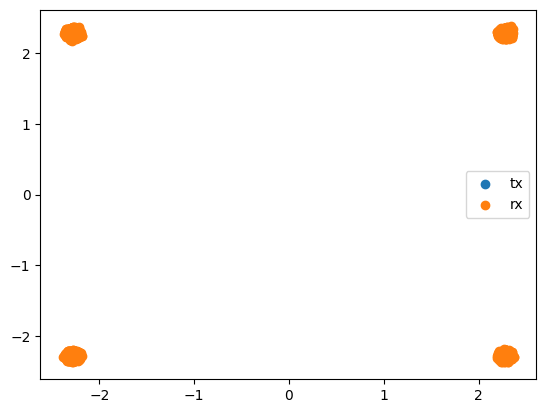

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage9: -8.252120561623885 dBm
Psig stage9: -8.0 dBm
Pnoise stage9: -48.274179801166746 dBm
NMSE stage9: -40.277125705237076 dB
Noise variance: -63.0760043827611 dBm


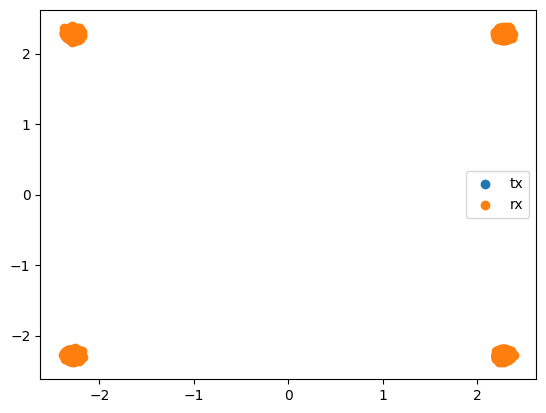

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage10: -8.2519141569605 dBm
Psig stage10: -8.0 dBm
Pnoise stage10: -47.816419415352094 dBm
NMSE stage10: -39.819806509424566 dB
Noise variance: -63.062760089913624 dBm


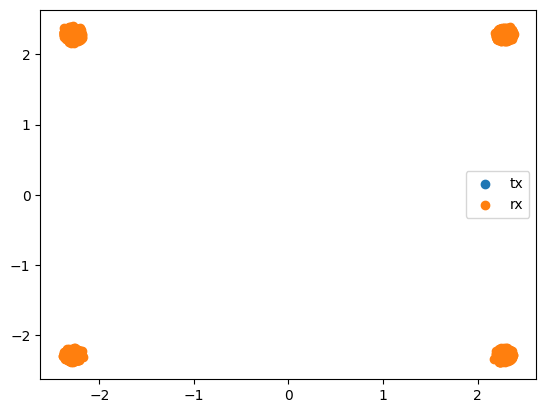

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage11: -8.244434157501123 dBm
Psig stage11: -8.0 dBm
Pnoise stage11: -47.402098616170775 dBm
NMSE stage11: -39.404320664354664 dB
Noise variance: -63.072159480291525 dBm


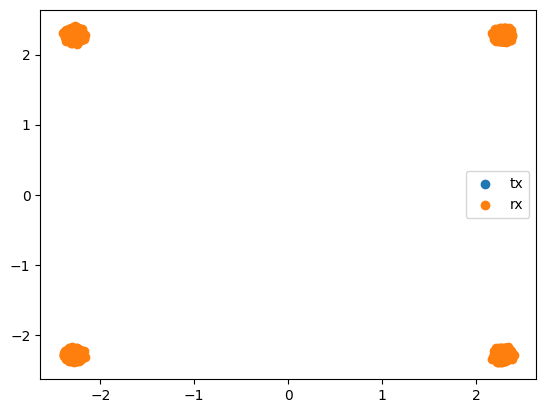

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage12: -8.234989732874322 dBm
Psig stage12: -8.0 dBm
Pnoise stage12: -47.03865573352661 dBm
NMSE stage12: -39.04133243550087 dB
Noise variance: -63.05330797359474 dBm


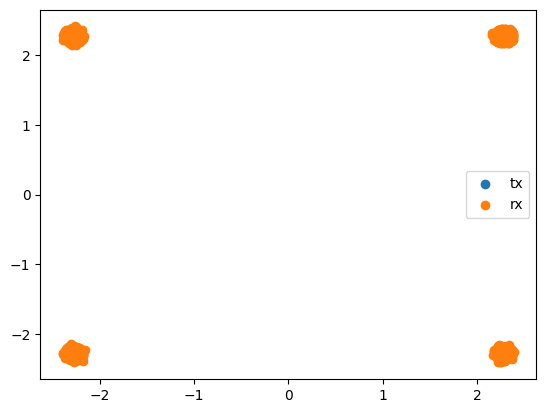

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage13: -8.218634451541577 dBm
Psig stage13: -8.0 dBm
Pnoise stage13: -46.687439059617326 dBm
NMSE stage13: -38.691528427701996 dB
Noise variance: -63.06605622592765 dBm


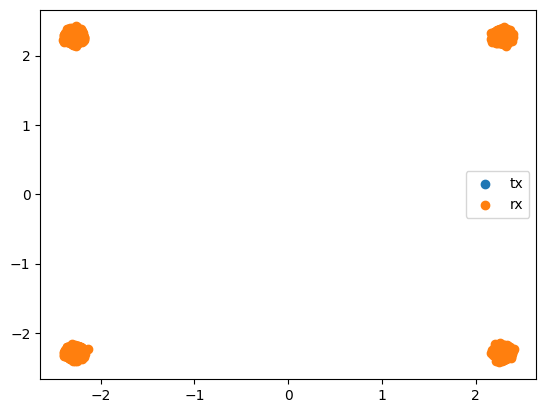

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage14: -8.198423632638807 dBm
Psig stage14: -8.0 dBm
Pnoise stage14: -46.363243652732024 dBm
NMSE stage14: -38.36724476240065 dB
Noise variance: -63.074526197644474 dBm


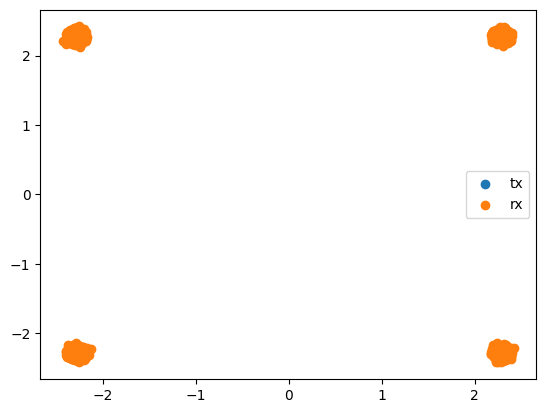

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage15: -8.168956600808011 dBm
Psig stage15: -8.0 dBm
Pnoise stage15: -46.053525331301316 dBm
NMSE stage15: -38.05750823901427 dB
Noise variance: -63.07336507558639 dBm


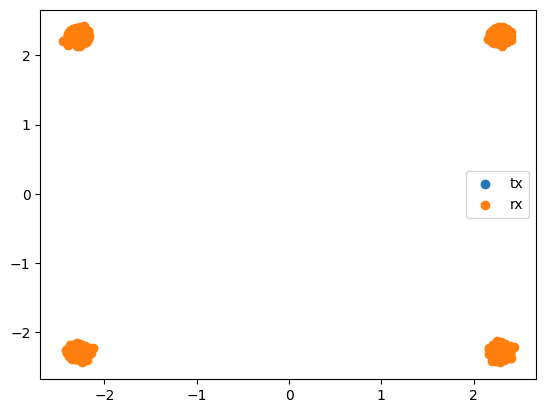

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage16: -8.134035123858656 dBm
Psig stage16: -8.0 dBm
Pnoise stage16: -45.74050275500539 dBm
NMSE stage16: -37.74654560991977 dB
Noise variance: -63.05883669811376 dBm


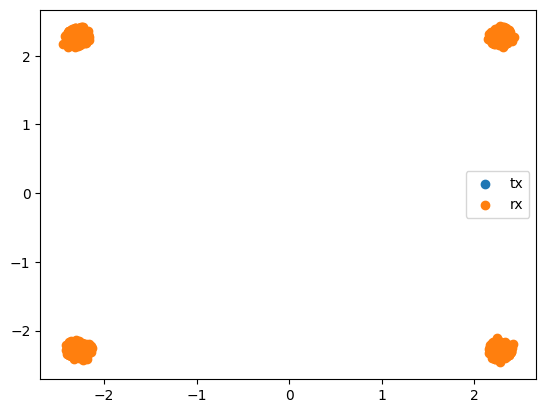

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage17: -8.092686013920309 dBm
Psig stage17: -8.0 dBm
Pnoise stage17: -45.43361140613463 dBm
NMSE stage17: -37.4413840684156 dB
Noise variance: -63.0726386022984 dBm


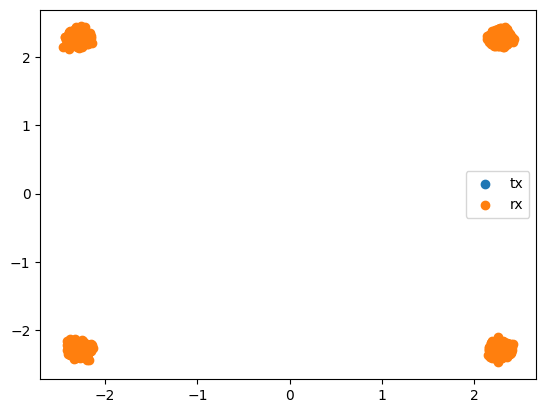

Psig_in utils: -8.0 dBm
X_time utils: -7.999999999999999 dBm
Psig_in stage18: -8.0499319288334 dBm
Psig stage18: -8.0 dBm
Pnoise stage18: -45.15925000525207 dBm
NMSE stage18: -37.16761962630542 dB
Noise variance: -63.05598917343612 dBm
7.237241992975055
Stripe: 0
RU 0: 4.043000008668694
RU 1: 4.04550378401105
RU 2: 4.0449690640554
RU 3: 4.0467645662283385
RU 4: 4.048090866336536
RU 5: 4.0490430013542955
RU 6: 4.051281375659799
RU 7: 4.052744277488057
RU 8: 4.052158829578088
RU 9: 4.053585167800328
RU 10: 4.05570142156313
RU 11: 4.057062482242202
RU 12: 4.058871298371851
RU 13: 4.058562813040924
RU 14: 4.0618398866558625
RU 15: 4.063072555861765
RU 16: 4.064281260968971
RU 17: 4.065410277152101
RU 18: 4.066760428829778
RU 19: 1.0
Stripe: 1
RU 0: 1.0
RU 1: 1.0
RU 2: 1.0
RU 3: 1.0
RU 4: 1.0
RU 5: 1.0
RU 6: 1.0
RU 7: 1.0
RU 8: 1.0
RU 9: 1.0
RU 10: 1.0
RU 11: 1.0
RU 12: 1.0
RU 13: 1.0
RU 14: 1.0
RU 15: 1.0
RU 16: 1.0
RU 17: 1.0
RU 18: 1.0
RU 19: 1.0
Stripe: 2
RU 0: 1.0
RU 1: 1.0
RU 2: 1.0
R

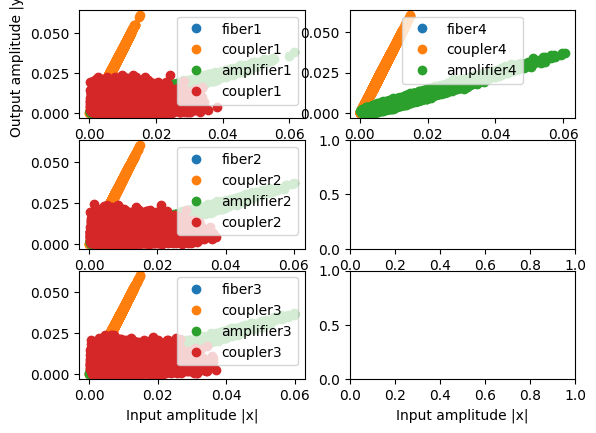

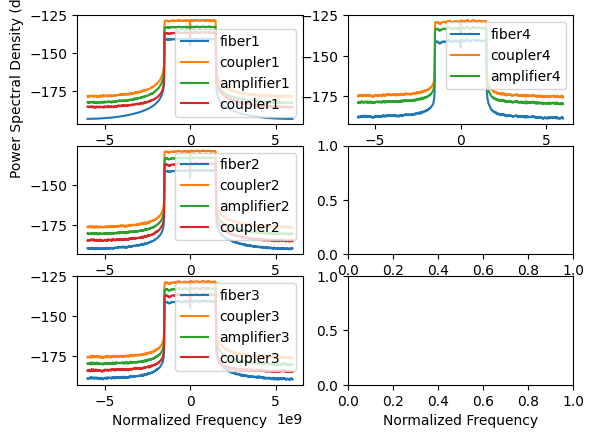

In [21]:
ru_shift = [0, 0, 0, 0]
stripes[0].active_unit = 19
print(calculate_papr(ofdm_time_after_cu))
y, imdata = stripes[0].transmit(ofdm_time_after_cu, ru_shift)
print(calculate_papr(imdata[3]))

fig, fig2 = plotter.plot_im_data_tx(imdata[1:(4*4)+1], wf)

for idx, stripe in enumerate(stripes):
    print(f"Stripe: {idx}")
    for jdx, ru in enumerate(stripe.radio_units):
        print(f"RU {jdx}: {ru.boost_amp.gain}")

NMSE: -37.16761962630542
BER: 0.0


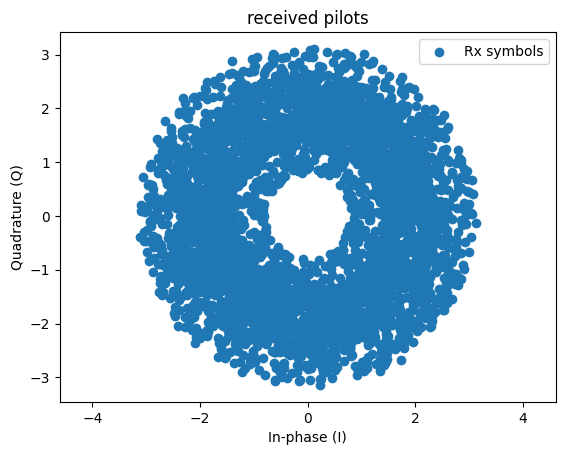

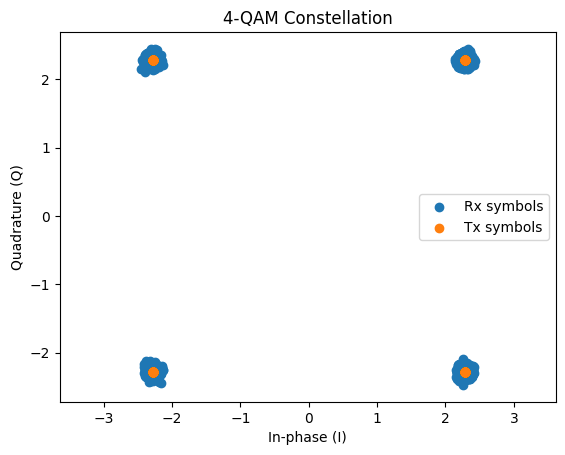

In [22]:
y_combined_freq = wf.ofdm_time_to_freq(imdata[-5])
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)

# sanity check
rx_subc = wf.extract_subcarriers(y_combined_freq)
# look at a few carriers around pilots and data
wf.plot_constellation(rx_subc[0, wf.pilot_indices], title="received pilots")

# channel estimation
subc = wf.extract_subcarriers(y_combined_freq)
H_est = wf.channel_estimate_ls(subc)

# equalization
eq_subc = wf.equalize_one_tap(subc, H_est)

nmse = np.sum(np.abs(eq_subc - xsubc) ** 2) / np.sum(np.abs(xsubc) ** 2)

# Demap data carriers and rebuild stream
data_symbols = wf.demap_data_from_grid(eq_subc).flatten()  # these are the received QAM symbols

y_qam = data_symbols

# quick sanity
assert y_qam.shape[0] == qam.shape[0], f"Lengths differ: rx {y_qam.shape[0]} tx {qam.shape[0]}"

wf.plot_constellation(eq_subc, symbols_tx=xsubc)

y_bits = wf.qam_to_bits(y_qam)

ber = wf.compute_ber(bits, y_bits)
print(f"NMSE: {10 * np.log10(nmse)}")
print(f"BER: {ber}")

In [23]:
import matplotlib.pyplot as plt

rx_subc shape: (10, 4096)
xsubc shape: (10, 4096)
xsubc: [-2.27976982+2.27976982j  2.27976982-2.27976982j -2.27976982+2.27976982j
 -2.27976982+2.27976982j  2.27976982+2.27976982j -2.27976982-2.27976982j
  2.27976982+2.27976982j  2.27976982-2.27976982j  2.27976982-2.27976982j
  2.27976982+2.27976982j  2.27976982+2.27976982j  2.27976982-2.27976982j
 -2.27976982+2.27976982j -2.27976982-2.27976982j -2.27976982+2.27976982j
  2.27976982+2.27976982j -2.27976982+2.27976982j -2.27976982+2.27976982j
 -2.27976982+2.27976982j -2.27976982+2.27976982j]


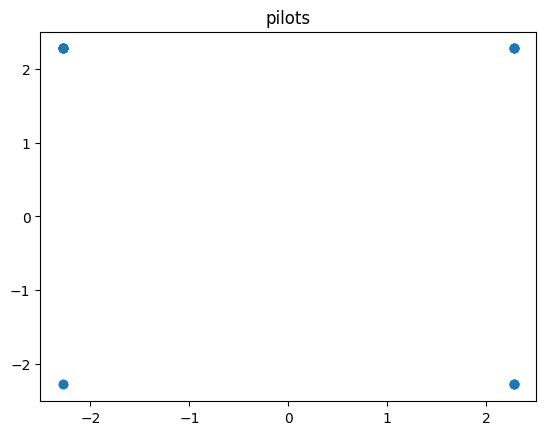

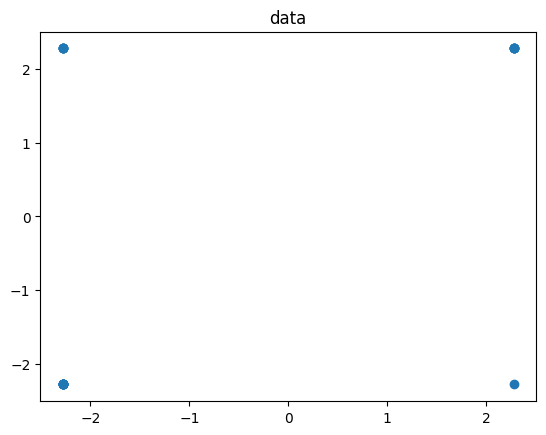

In [24]:
print(f'rx_subc shape: {rx_subc.shape}')
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)
print(f'xsubc shape: {xsubc.shape}')
symbolidx = 0
nr_symbols_to_print = 20
print(f'xsubc: {xsubc[symbolidx, :nr_symbols_to_print]}')

plt.title('pilots')
plt.scatter(xsubc[symbolidx,:nr_symbols_to_print].real, xsubc[symbolidx,:nr_symbols_to_print].imag)
plt.show()

plt.title('data')
symbolidx = 1
plt.scatter(xsubc[symbolidx,:nr_symbols_to_print].real, xsubc[symbolidx,:nr_symbols_to_print].imag)
plt.show()
